In [1]:
import warnings
from functools import partial

import iris
import matplotlib.pyplot as plt
import paths
from aeolus.calc import (
    last_n_day_mean,
    time_mean,
)
from aeolus.const import init_const
from aeolus.coord import (
    get_cube_rel_days,
    interp_cube_from_height_to_pressure_levels,
    isel,
)
from aeolus.lfric import load_lfric_raw
from aeolus.model import lfric
from aeolus.plot import figsave
from common import (
    EXPERIMENTS,
    ke_spectrum,
    lfric_callback_uniform_height,
)

warnings.filterwarnings("ignore")
iris.FUTURE.date_microseconds = True

print(*EXPERIMENTS.keys(), sep=" ")

shj_c48_l32 shj_c24_l32 shj_c96_l32 shj_c48_l16 shj_c48_l64 dhj_c48_l66 dhj_c24_l66 dhj_c96_l66


In [2]:
exp_key = "shj_c48_l32"
ds_ll = load_lfric_raw(
    sorted(
        (
            paths.data_work
            / "lfric"
            / EXPERIMENTS[exp_key].group
            / EXPERIMENTS[exp_key].label
        ).glob("lfric_diag_latlon*.nc")
    )[:],
    callback=partial(
        lfric_callback_uniform_height,
        model_top_height=EXPERIMENTS[exp_key].const.domain_height.data,
    ),
)
print(ds_ll)

0: air_pressure / (Pa)                 (time: 120; level_height: 33; latitude: 90; longitude: 144)
1: air_temperature / (K)               (time: 120; level_height: 33; latitude: 90; longitude: 144)
2: divergence_of_wind / (s-1)          (time: 120; level_height: 32; latitude: 90; longitude: 144)
3: eastward_wind / (m s-1)             (time: 120; level_height: 32; latitude: 90; longitude: 144)
4: northward_wind / (m s-1)            (time: 120; level_height: 32; latitude: 90; longitude: 144)
5: temperature_increment_from_external_forcing / (K) (time: 120; level_height: 33; latitude: 90; longitude: 144)
6: upward_air_velocity / (m s-1)       (time: 120; level_height: 32; latitude: 90; longitude: 144)
7: vertical_vorticity / (s-1)          (time: 120; level_height: 32; latitude: 90; longitude: 144)


# TODO: REGRID CUBED_SPHERE DATA

In [3]:
spec = ke_spectrum(
    ds_ll.extract_cube("u_in_w3"),
    ds_ll.extract_cube("v_in_w3"),
    rsphere=EXPERIMENTS[exp_key].const.radius.data.item(),
)

Text(0.5, 1.0, 'Shallow Hot Jupiter | shj_c48_l32\nlevel_height = 3142348 m, ')

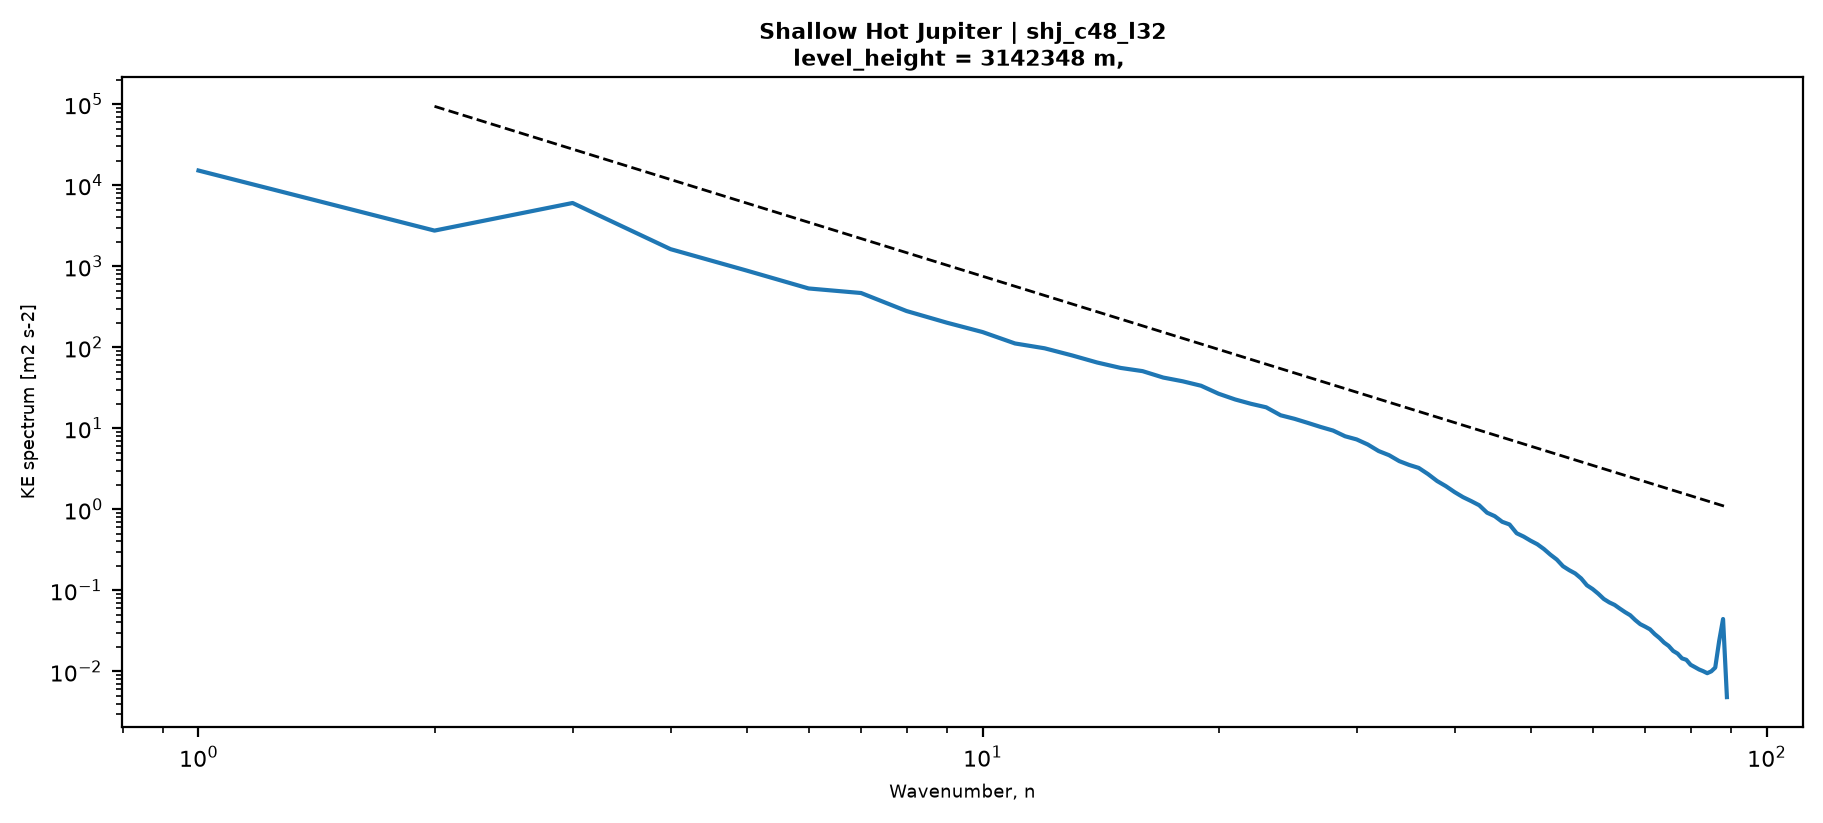

In [5]:
idx_lev = 30  # index into level_height

spec1d = last_n_day_mean(isel(spec, lfric.z, idx_lev), 300)

x = spec1d.coord("wavenumber").points
y = spec1d.data

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")

ax.loglog(x, y)

x_ref = x[1:]  # avoid x=0 if present
p = -3
x0, y0 = (
    x_ref[len(x_ref) // 4],
    y[len(x_ref) // 4] * 3,
)  # anchor + vertical offset so it doesn't overlap
ax.loglog(x_ref, y0 * (x_ref / x0) ** p, "k--", lw=1, label=r"$k^{-5/3}$")

ax.set_xlabel("Wavenumber, $n$")
ax.set_ylabel(f"KE spectrum [{spec.units}]")
ax.set_title(
    "\n".join(
        [
            f"{EXPERIMENTS[exp_key].title} | {exp_key}",
            f"level_height = {spec.coord(lfric.z).points[idx_lev].item():.0f} m, ",
        ]
    )
)